<a href="https://colab.research.google.com/github/JeetRaman21/Demo/blob/main/Day2_LPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch   # PyTorch — our deep-learning toolkit (already installed in Colab)

# Is a GPU available?
print("GPU available:", torch.cuda.is_available())

# We'll send our work to the GPU if there is one, otherwise the CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

GPU available: True
Using device: cuda


In [ ]:
import torch

a = torch.tensor(7)                       # a single number (scalar)
b = torch.tensor([1.0, 2.0, 3.0])         # a list (vector)
c = torch.tensor([[1.0, 2.0], [3.0, 4.0]]) # a 2x2 grid (matrix)

print("a:", a, "| shape:", a.shape)       # shape: torch.Size([])  -> just one number shape tells size
print("b:", b, "| shape:", b.shape)       # shape: torch.Size([3]) -> 3 numbers in a row
print("c:\n", c, "| shape:", c.shape)     # shape: torch.Size([2, 2]) -> 2 rows, 2 columns

a: tensor(7) | shape: torch.Size([])
b: tensor([1., 2., 3.]) | shape: torch.Size([3])
c:
 tensor([[1., 2.],
        [3., 4.]]) | shape: torch.Size([2, 2])


In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])

print("Add:     ", x + y)        # [11, 22, 33] — element by element
print("Multiply:", x * y)        # [10, 40, 90]
print("Sum of x:", x.sum())      # 6.0

Add:      tensor([11., 22., 33.])
Multiply: tensor([10., 40., 90.])
Sum of x: tensor(6.)


In [ ]:
# Make a number we want to "learn", and tell PyTorch to track its gradient
w = torch.tensor(3.0, requires_grad=True)

# A pretend "error" that depends on w  (here: error = w squared)
error = w ** 2

# Ask PyTorch: which way should w move to reduce the error?
error.backward()

print("Current w:", w.item())
print("Gradient (slope) at w:", w.grad.item())   # 6.0 -> error rises steeply if w grows
# A positive slope means: to REDUCE error, make w smaller. That's the 'downhill' direction.

Current w: 3.0
Gradient (slope) at w: 6.0


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch

# Load the flowers
iris = load_iris()
X = iris.data         # 150 flowers x 4 measurements
y = iris.target       # the species: 0, 1, or 2

print("Inputs shape:", X.shape)    # (150, 4) -> 150 flowers, 4 numbers each
print("First flower:", X[0], "-> species", y[0])

# Split into train / test (same idea as Day 1: hide some data to grade honestly)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Turn the data into tensors and send to our device (GPU/CPU)
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_test  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test,  dtype=torch.long).to(device)

print("Ready: training on", X_train.shape[0], "flowers")

Inputs shape: (150, 4)
First flower: [5.1 3.5 1.4 0.2] -> species 0
Ready: training on 120 flowers


In [ ]:
import torch.nn as nn

# Define the network as a class. Think of it as a recipe for the layers.
class FlowerNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Layer 1: 4 inputs -> 16 hidden neurons
        self.layer1 = nn.Linear(4, 16)
        # The "squish" function that lets the network learn curves, not just lines
        self.relu = nn.ReLU()
        # Layer 2: 16 hidden neurons -> 3 outputs (one score per species)
        self.layer2 = nn.Linear(16, 3)

    # forward() describes how data flows through the layers
    def forward(self, x):
        x = self.layer1(x)   # multiply + add
        x = self.relu(x)     # squish
        x = self.layer2(x)   # multiply + add -> 3 scores
        return x

# Create the network and send it to the GPU/CPU
model = FlowerNet().to(device)
print(model)

FlowerNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)


In [ ]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)   # lr = step size

# Train for 100 rounds (each round = one full taste-test loop over the data)
for epoch in range(1000):
    # 1. GUESS — predict scores for every training flower
    predictions = model(X_train)

    # 2. CHECK — how wrong were we?
    loss = loss_function(predictions, y_train)

    # 3. ADJUST — clear old gradients, find new ones, take a downhill step
    optimizer.zero_grad()   # reset the slope tracker
    loss.backward()         # autograd works out which way is downhill
    optimizer.step()        # nudge every weight that way

    # Print progress every 20 rounds
    if (epoch + 1) % 20 == 0:
        print(f"Round {epoch+1:3d} | error (loss): {loss.item():.3f}")

Round  20 | error (loss): 0.737
Round  40 | error (loss): 0.460
Round  60 | error (loss): 0.324
Round  80 | error (loss): 0.223
Round 100 | error (loss): 0.157
Round 120 | error (loss): 0.120
Round 140 | error (loss): 0.100
Round 160 | error (loss): 0.088
Round 180 | error (loss): 0.080
Round 200 | error (loss): 0.075
Round 220 | error (loss): 0.071
Round 240 | error (loss): 0.068
Round 260 | error (loss): 0.065
Round 280 | error (loss): 0.063
Round 300 | error (loss): 0.061
Round 320 | error (loss): 0.060
Round 340 | error (loss): 0.059
Round 360 | error (loss): 0.057
Round 380 | error (loss): 0.056
Round 400 | error (loss): 0.055
Round 420 | error (loss): 0.054
Round 440 | error (loss): 0.054
Round 460 | error (loss): 0.053
Round 480 | error (loss): 0.052
Round 500 | error (loss): 0.051
Round 520 | error (loss): 0.051
Round 540 | error (loss): 0.050
Round 560 | error (loss): 0.050
Round 580 | error (loss): 0.049
Round 600 | error (loss): 0.049
Round 620 | error (loss): 0.048
Round 64

In [ ]:
# Turn off learning for testing (we're just checking, not adjusting)
model.eval()
with torch.no_grad():                      # don't track gradients — faster
    test_scores = model(X_test)            # 3 scores per flower
    predicted = test_scores.argmax(dim=1)  # pick the species with the highest score
    accuracy = (predicted == y_test).float().mean()

print(f"Test accuracy: {accuracy.item()*100:.1f}%")   # usually ~95-100%

Test accuracy: 100.0%


In [ ]:
import torch

# Device setup for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# A recipe to turn each image into a tensor of pixel numbers
to_tensor = transforms.ToTensor()

# Download MNIST (Colab fetches it automatically)
train_data = datasets.MNIST(root="data", train=True,  download=True, transform=to_tensor)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=to_tensor)

print("Training images:", len(train_data))   # 60000
print("One image shape:", train_data[0][0].shape)  # [1, 28, 28] -> 1 colour, 28x28 pixels
print("Its label:", train_data[0][1])         # the digit it shows

Using device: cuda
Training images: 60000
One image shape: torch.Size([1, 28, 28])
Its label: 5


In [ ]:
# DataLoader serves the data in shuffled batches of 64
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Peek at one batch
images, labels = next(iter(train_loader))
print("One batch of images:", images.shape)   # [64, 1, 28, 28] -> 64 images at once
print("One batch of labels:", labels.shape)   # [64]

One batch of images: torch.Size([64, 1, 28, 28])
One batch of labels: torch.Size([64])


In [ ]:

import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()           # turn 28x28 image into a row of 784 numbers
        self.layer1 = nn.Linear(784, 128)     # 784 pixels -> 128 hidden neurons
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)        # randomly ignore 20% of neurons while training
        self.layer2 = nn.Linear(128, 10)      # 128 -> 10 outputs (one per digit 0-9)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

model = DigitNet().to(device)
print(model)

DigitNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
import torch.optim as optim

loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()   # tell the network we're training (dropout ON)

for epoch in range(3):                       # 3 full passes is plenty for MNIST
    running_loss = 0.0
    for images, labels in train_loader:      # one batch at a time
        images, labels = images.to(device), labels.to(device)

        # The same taste-test loop, per batch:
        predictions = model(images)               # 1. guess
        loss = loss_function(predictions, labels) # 2. check
        optimizer.zero_grad()                     # 3a. reset slopes
        loss.backward()                           # 3b. find downhill direction
        optimizer.step()                          # 3c. nudge the weights

        running_loss += loss.item()

    avg = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} | average error: {avg:.3f}")

Epoch 1 | average error: 0.105
Epoch 2 | average error: 0.090
Epoch 3 | average error: 0.077


In [ ]:
model.eval()    # dropout OFF for testing
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted = model(images).argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")   # usually ~97%

Test accuracy: 97.54%


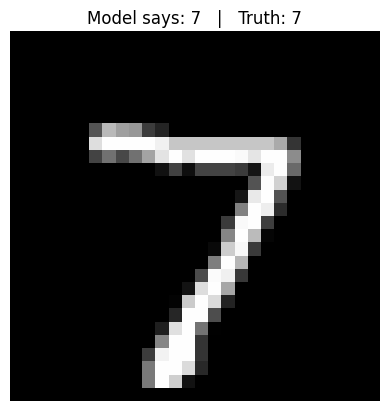

In [ ]:
import matplotlib.pyplot as plt

# Grab one test image
img, true_label = test_data[0]
model.eval()
with torch.no_grad():
    guess = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Model says: {guess}   |   Truth: {true_label}")
plt.axis("off")
plt.show()